<div style="background: linear-gradient(135deg, #0f172a, #1d4ed8); color: white; padding: 22px; border-radius: 14px;">
  <h1 style="margin: 0;">Driver Drowsiness Detection with Continuous Drowsiness Index</h1>
  <p style="margin: 10px 0 0 0; font-size: 16px;">
    ARTI 560 Computer Vision Project Notebook<br>
    Transfer Learning with MobileNetV2 on the Driver Drowsiness Dataset (DDD)
  </p>
</div>

### Notebook Purpose
This notebook builds a complete end-to-end pipeline for binary driver drowsiness detection and converts model outputs into a continuous **Drowsiness Index** in the range `[0, 1]`.

### Alignment with the Course Project Guideline
Based on the project outline PDF, this notebook is designed to support a strong final submission by emphasizing:
- reproducibility through fixed random seeds and saved data splits
- clear methodology with modular, well-commented code
- dataset description, preprocessing, and train/validation/test partitioning
- evaluation with accuracy, F1-score, and classification report
- GitHub-ready outputs including model artifacts and exported CSV/JSON files


## Project Objectives and Mathematical Formulation

We use a pretrained **MobileNetV2** backbone to classify images into two classes:
- `0`: Non Drowsy
- `1`: Drowsy

The classifier outputs a probability for the positive class. We directly interpret this probability as the continuous **Drowsiness Index (DI)**:

$$
DI_i = P(y_i = 1 \\mid x_i)
$$

To reduce short-term fluctuations, we smooth the index using a moving average with window size $w$:

$$
\\widetilde{DI}_i = \\frac{1}{w} \\sum_{k=0}^{w-1} DI_{i-k}
$$

### What This Notebook Covers
1. Dataset discovery and inspection
2. Preprocessing and minimal augmentation
3. Stratified 70/15/15 split
4. MobileNetV2 transfer learning model
5. Training with callbacks
6. Raw probability prediction on the test set
7. Continuous Drowsiness Index smoothing
8. Evaluation, plots, and artifact export

> **Note:** The DDD dataset is image-based rather than a true temporal video stream. For demonstration, smoothing is applied after sorting the test predictions by filename to obtain a deterministic sequence. In a deployment setting, smoothing should be applied in real chronological frame order.


## Step 1: Locate the Dataset and Build Image Metadata

The notebook expects the downloaded dataset to contain two folders:
- `Drowsy/`
- `Non Drowsy/`

To make the notebook easy to reuse, we automatically search for a directory containing both class folders inside the current project workspace. Then we build a metadata table containing:
- full image path
- filename
- class name
- numeric label


In [1]:
import json
import os
import random
import time
from pathlib import Path

os.environ["DML_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
# Define global configuration values so the notebook is reproducible and easy to tune.
# These settings control image size, batching, training duration, and export locations.
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
INITIAL_EPOCHS = 15
LEARNING_RATE = 1e-4
SMOOTHING_WINDOW = 5

# Prefer the exact project path on this machine, then fall back to the current working directory.
DEFAULT_PROJECT_ROOT = Path(r"C:\\Users\\lenovo\\Desktop\\Alhnouf CV")
PROJECT_ROOT = DEFAULT_PROJECT_ROOT if DEFAULT_PROJECT_ROOT.exists() else Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Driver Drowsiness Dataset (DDD)"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
SPLIT_DIR = ARTIFACTS_DIR / "data_splits"
MODEL_PATH = ARTIFACTS_DIR / "best_mobilenetv2_drowsiness.keras"
HISTORY_PATH = ARTIFACTS_DIR / "training_history.csv"
DI_CSV_PATH = ARTIFACTS_DIR / "drowsiness_index.csv"
DETAILED_PREDICTIONS_PATH = ARTIFACTS_DIR / "test_predictions_detailed.csv"
EVALUATION_JSON_PATH = ARTIFACTS_DIR / "evaluation_summary.json"
CLASSIFICATION_REPORT_PATH = ARTIFACTS_DIR / "classification_report.txt"
CLASSIFICATION_REPORT_CSV_PATH = ARTIFACTS_DIR / "classification_report.csv"

# Create output folders in advance so later cells can save results without failing.
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# Set random seeds across Python, NumPy, and TensorFlow for reproducibility.
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    keras.utils.set_random_seed(seed)

set_global_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpus) > 0
DEVICE_NAME = "/GPU:0" if GPU_AVAILABLE else "/CPU:0"

print("Project configuration initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Configured dataset root: {DATASET_ROOT}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"TensorFlow GPUs found: {gpus}")
print(f"Training device: {DEVICE_NAME}")


Project configuration initialized.
Project root: C:\Users\lenovo\Desktop\Alhnouf CV
Configured dataset root: C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drowsiness Dataset (DDD)
Artifacts directory: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts
TensorFlow GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training device: /GPU:0


In [3]:
# Build reusable helper functions for dataset discovery and metadata construction.
# This keeps the later cells concise and makes the workflow easier to debug.
def find_dataset_root(project_root: Path, preferred_dataset_root: Path = None) -> Path:
    """Search a small set of likely locations for the dataset root."""
    if preferred_dataset_root is not None:
        if (preferred_dataset_root / "Drowsy").is_dir() and (preferred_dataset_root / "Non Drowsy").is_dir():
            return preferred_dataset_root

    candidate_dirs = [project_root]

    # Check first-level directories because Kaggle downloads are often extracted to a single folder.
    for child in project_root.iterdir():
        if child.is_dir():
            candidate_dirs.append(child)

    # Check one more level to support nested extraction folders without scanning every image file.
    for child in project_root.iterdir():
        if child.is_dir():
            for grandchild in child.iterdir():
                if grandchild.is_dir():
                    candidate_dirs.append(grandchild)

    for candidate in candidate_dirs:
        if (candidate / "Drowsy").is_dir() and (candidate / "Non Drowsy").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not find a dataset folder containing both 'Drowsy' and 'Non Drowsy'. "
        "Download and extract the Kaggle dataset inside the project folder, then rerun this cell."
    )


def build_metadata_dataframe(dataset_root: Path) -> pd.DataFrame:
    """Create a structured dataframe describing every image in the dataset."""
    allowed_suffixes = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    class_map = {"Non Drowsy": 0, "Drowsy": 1}
    records = []

    for class_name, label in class_map.items():
        class_dir = dataset_root / class_name
        for file_path in sorted(class_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in allowed_suffixes:
                records.append(
                    {
                        "filepath": str(file_path.resolve()),
                        "filename": file_path.name,
                        "class_name": class_name,
                        "label": label,
                    }
                )

    if not records:
        raise ValueError("No supported image files were found in the dataset directories.")

    metadata_df = pd.DataFrame(records)
    metadata_df = metadata_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return metadata_df


def summarize_distribution(metadata_df: pd.DataFrame) -> pd.DataFrame:
    """Compute a compact class distribution summary for reporting."""
    summary_df = (
        metadata_df.groupby(["class_name", "label"])
        .size()
        .reset_index(name="image_count")
        .sort_values("label")
    )
    summary_df["percentage"] = 100.0 * summary_df["image_count"] / len(metadata_df)
    return summary_df

print("Dataset helper functions are ready.")


Dataset helper functions are ready.


Dataset root found at: C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drowsiness Dataset (DDD)
Total images discovered: 41,793


,class_name,label,image_count,percentage
1,Non Drowsy,0,19445,46.52693
0,Drowsy,1,22348,53.47307


,filepath,filename,class_name,label
0,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,O0256.png,Drowsy,1
1,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,u0040.png,Non Drowsy,0
2,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,l0045.png,Non Drowsy,0
3,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,j0199.png,Non Drowsy,0
4,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,d0055.png,Non Drowsy,0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_31432\807809008.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distribution_df, x="class_name", y="image_count", palette=["#0f766e", "#b45309"])


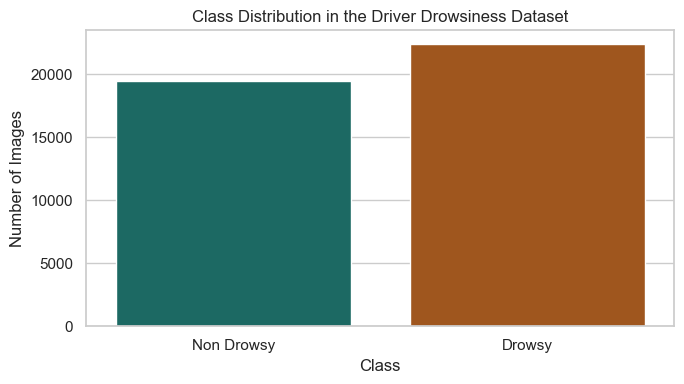

In [4]:
# Locate the dataset, build the metadata table, and inspect the class balance.
# These values will also be useful later when writing the final report.
dataset_root = find_dataset_root(PROJECT_ROOT, DATASET_ROOT)
metadata_df = build_metadata_dataframe(dataset_root)
distribution_df = summarize_distribution(metadata_df)

print(f"Dataset root found at: {dataset_root}")
print(f"Total images discovered: {len(metadata_df):,}")
display(distribution_df)
display(metadata_df.head())

# Visualize the overall class distribution for a quick sanity check.
plt.figure(figsize=(7, 4))
sns.barplot(data=distribution_df, x="class_name", y="image_count", palette=["#0f766e", "#b45309"])
plt.title("Class Distribution in the Driver Drowsiness Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## Step 2: Create Stratified Train, Validation, and Test Splits

We partition the dataset into:
- **70%** training
- **15%** validation
- **15%** test

A stratified split preserves the original class balance in each subset, which is important for fair evaluation and stable training behavior.


In [5]:
# Split the metadata table into train/validation/test partitions using stratification.
# We also export the split files to disk so the experiment can be reproduced exactly.
def stratified_train_val_test_split(metadata_df: pd.DataFrame):
    """Return a 70/15/15 stratified split."""
    train_val_df, test_df = train_test_split(
        metadata_df,
        test_size=0.15,
        stratify=metadata_df["label"],
        random_state=SEED,
    )

    validation_fraction_of_remaining = 0.15 / 0.85
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=validation_fraction_of_remaining,
        stratify=train_val_df["label"],
        random_state=SEED,
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    return train_df, val_df, test_df


train_df, val_df, test_df = stratified_train_val_test_split(metadata_df)

# Save the exact splits for reproducibility and report documentation.
train_df.to_csv(SPLIT_DIR / "train_split.csv", index=False)
val_df.to_csv(SPLIT_DIR / "validation_split.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test_split.csv", index=False)

# Build a compact table summarizing sizes and class balance for each split.
split_frames = []
for split_name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    counts = split_df["class_name"].value_counts().to_dict()
    split_frames.append(
        {
            "split": split_name,
            "num_images": len(split_df),
            "num_non_drowsy": counts.get("Non Drowsy", 0),
            "num_drowsy": counts.get("Drowsy", 0),
        }
    )

split_summary_df = pd.DataFrame(split_frames)
print("Data split completed.")
display(split_summary_df)


Data split completed.


,split,num_images,num_non_drowsy,num_drowsy
0,Train,29255,13611,15644
1,Validation,6269,2917,3352
2,Test,6269,2917,3352


## Step 3: Visualize Example Images from Each Class

Before training, it is good practice to inspect a small sample of images. This helps verify that:
- the labels match the folder names
- the data is readable and correctly loaded
- the classes exhibit visually meaningful differences


Displaying sample training images...


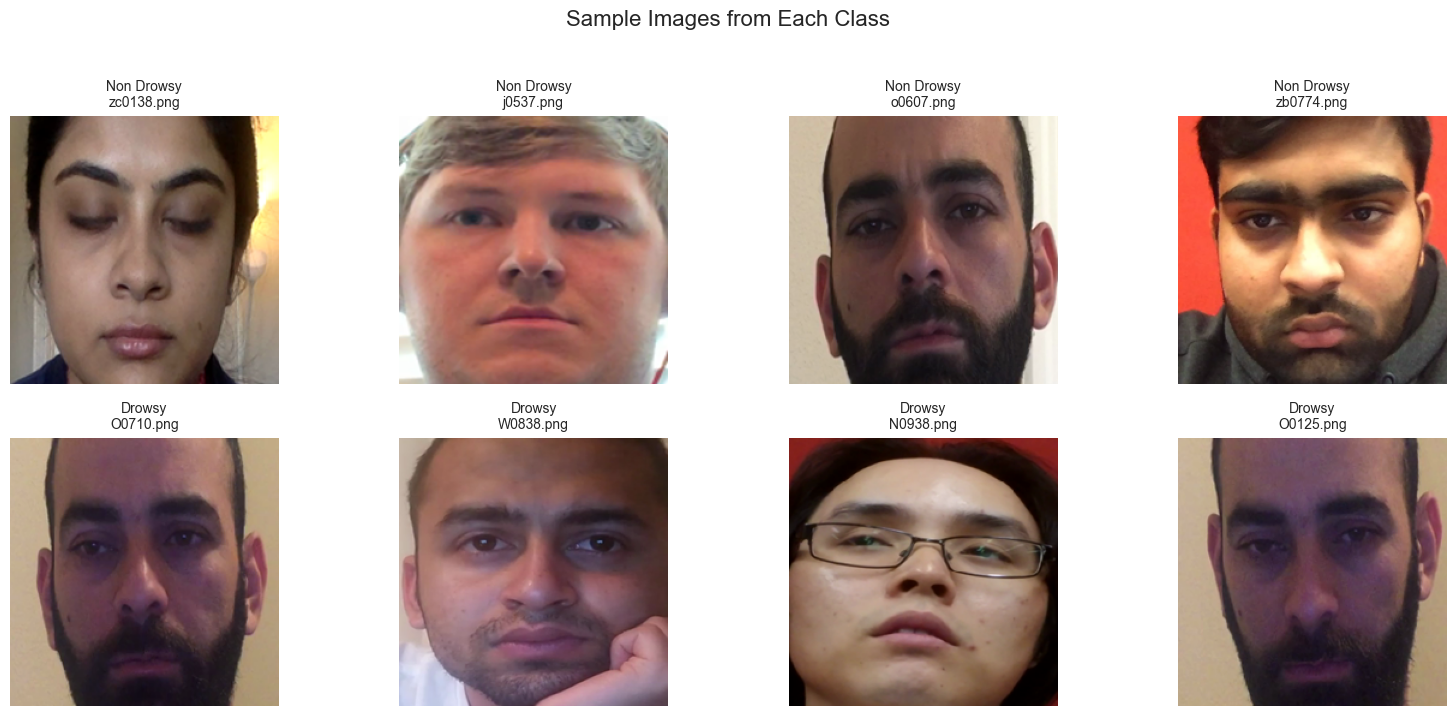

In [6]:
# Display a few random images from each class so we can visually verify the data.
# Using the training split helps confirm what the model will actually learn from.
def plot_sample_images(split_df: pd.DataFrame, image_size=(224, 224), samples_per_class: int = 4) -> None:
    class_names = ["Non Drowsy", "Drowsy"]
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(4 * samples_per_class, 7))

    for row_index, class_name in enumerate(class_names):
        class_examples = split_df[split_df["class_name"] == class_name].sample(
            n=samples_per_class,
            random_state=SEED,
        )

        for col_index, (_, row) in enumerate(class_examples.iterrows()):
            axis = axes[row_index, col_index]
            image = keras.utils.load_img(row["filepath"], target_size=image_size)
            axis.imshow(image)
            axis.set_title(f"{class_name}\n{row['filename']}", fontsize=10)
            axis.axis("off")

    plt.suptitle("Sample Images from Each Class", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


print("Displaying sample training images...")
plot_sample_images(train_df, image_size=IMAGE_SIZE, samples_per_class=4)


## Step 4: Build the ImageDataGenerator Pipeline

This pipeline performs the required preprocessing steps:
- resize to **224 x 224**
- normalize pixel values to **[0, 1]**
- apply minimal augmentation on the training set only:
  - horizontal flip
  - small rotation
  - brightness adjustment

The training augmentation is intentionally light so the model learns robust features without heavily distorting facial cues.

I am using `ImageDataGenerator` here because it is simpler and more stable on this Windows setup while still matching the project requirements.


In [7]:
# Build generators for train, validation, and test.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True,
    rotation_range=10,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest",
)

eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_gen = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_gen = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Inspect one batch to confirm the shapes and numeric ranges are correct.
sample_batch_images, sample_batch_labels = next(train_gen)
train_gen.reset()
print("Image generators created successfully.")
print(f"Batch image tensor shape: {sample_batch_images.shape}")
print(f"Batch label tensor shape: {sample_batch_labels.shape}")
print(
    f"Image value range after preprocessing: [{sample_batch_images.min():.3f}, "
    f"{sample_batch_images.max():.3f}]"
)
print(f"Class mapping used by the generator: {train_gen.class_indices}")


Found 29255 validated image filenames belonging to 2 classes.
Found 6269 validated image filenames belonging to 2 classes.
Found 6269 validated image filenames belonging to 2 classes.
Image generators created successfully.
Batch image tensor shape: (8, 224, 224, 3)
Batch label tensor shape: (8,)
Image value range after preprocessing: [0.000, 1.000]
Class mapping used by the generator: {'Drowsy': 0, 'Non Drowsy': 1}


## Step 5: Build the MobileNetV2 Model

In this step, I use **MobileNetV2** with pretrained ImageNet weights as the base model.

The model structure is simple:
- MobileNetV2 without the top classification layer
- global average pooling
- dropout
- dense layer
- sigmoid output for binary classification

The images are already normalized to `[0, 1]`. Before passing them into MobileNetV2, they are rescaled to `[-1, 1]` to match the expected input range.


In [8]:
# Build and compile the transfer learning model.
# The base model is initially frozen so the classifier head can adapt to the new dataset.
def build_model(input_shape=(224, 224, 3), learning_rate: float = 1e-4):
    """Create a MobileNetV2-based binary classifier."""
    inputs = keras.Input(shape=input_shape, name="input_image")

    # Convert [0, 1] inputs to the range expected by ImageNet-pretrained MobileNetV2.
    x = layers.Rescaling(scale=2.0, offset=-1.0, name="mobilenet_input_rescaling")(inputs)

    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.30, name="dropout_1")(x)
    x = layers.Dense(128, activation="relu", name="dense_features")(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="drowsiness_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="mobilenetv2_drowsiness_detector")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model


keras.backend.clear_session()
model = build_model(input_shape=IMAGE_SIZE + (3,), learning_rate=LEARNING_RATE)
model.summary()


Model: "mobilenetv2_drowsiness_detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 mobilenet_input_rescaling (  (None, 224, 224, 3)      0         
 Rescaling)                                                      
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling (Glo  (None, 1280)             0         
 balAveragePooling2D)                                            
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                   

## Step 6: Train the Model with Proper Callbacks

Training uses three important callbacks:
- **EarlyStopping** to stop when validation performance stops improving
- **ModelCheckpoint** to save the best model automatically
- **ReduceLROnPlateau** to lower the learning rate when progress slows

We also use class weights to slightly compensate for the mild class imbalance in the dataset.


In [9]:
# Train the model and save the best-performing checkpoint.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(),
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}

steps_per_epoch = len(train_gen)
validation_steps = len(val_gen)
log_every_n_batches = max(1, steps_per_epoch // 20)

def format_seconds(seconds):
    minutes, seconds = divmod(int(seconds), 60)
    hours, minutes = divmod(minutes, 60)
    if hours > 0:
        return f"{hours}h {minutes}m {seconds}s"
    if minutes > 0:
        return f"{minutes}m {seconds}s"
    return f"{seconds}s"

class BatchProgressCallback(keras.callbacks.Callback):
    def __init__(self, total_steps, log_every):
        super().__init__()
        self.total_steps = total_steps
        self.log_every = log_every

    def on_train_begin(self, logs=None):
        self.training_start_time = time.time()
        print("Training started.")
        print(f"Training steps per epoch: {self.total_steps}")
        print(f"Validation steps: {validation_steps}")
        print("The first batch can take longer than usual while TensorFlow prepares everything.")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()
        print(f"\nEpoch {epoch + 1}/{INITIAL_EPOCHS}")

    def on_train_batch_end(self, batch, logs=None):
        current_step = batch + 1
        if current_step == 1 or current_step % self.log_every == 0 or current_step == self.total_steps:
            elapsed = time.time() - self.epoch_start_time
            loss = logs.get("loss", 0.0)
            accuracy = logs.get("accuracy", 0.0)
            print(
                f"  step {current_step}/{self.total_steps} - "
                f"loss: {loss:.4f} - accuracy: {accuracy:.4f} - elapsed: {format_seconds(elapsed)}"
            )

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start_time
        print(
            f"Epoch {epoch + 1} done - "
            f"loss: {logs.get('loss', 0.0):.4f} - accuracy: {logs.get('accuracy', 0.0):.4f} - "
            f"val_loss: {logs.get('val_loss', 0.0):.4f} - val_accuracy: {logs.get('val_accuracy', 0.0):.4f} - "
            f"time: {format_seconds(elapsed)}"
        )

callbacks = [
    BatchProgressCallback(total_steps=steps_per_epoch, log_every=log_every_n_batches),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.TerminateOnNaN(),
]

print("Starting training...")
print(f"Class weights: {class_weight_dict}")
print(f"Training on: {DEVICE_NAME}")
print(f"Batch size: {BATCH_SIZE}")

try:
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=INITIAL_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        workers=1,
        use_multiprocessing=False,
        max_queue_size=4,
        verbose=0,
    )
except tf.errors.ResourceExhaustedError:
    print("Out of memory during training. Try changing BATCH_SIZE to 4 and restart the kernel.")
    raise

history_df = pd.DataFrame(history.history)
history_df.to_csv(HISTORY_PATH, index=False)

print("Training finished.")
print(f"Best model saved to: {MODEL_PATH}")
print(f"Training history saved to: {HISTORY_PATH}")


Starting training...
Class weights: {0: 1.0746822423040188, 1: 0.9350230120173869}
Training on: /GPU:0
Batch size: 8
Training started.
Training steps per epoch: 3657
Validation steps: 784
The first batch can take longer than usual while TensorFlow prepares everything.

Epoch 1/15
  step 1/3657 - loss: 0.7425 - accuracy: 0.5000 - elapsed: 4s
  step 182/3657 - loss: 0.6710 - accuracy: 0.6257 - elapsed: 23s
  step 364/3657 - loss: 0.5893 - accuracy: 0.6930 - elapsed: 43s
  step 546/3657 - loss: 0.5328 - accuracy: 0.7331 - elapsed: 1m 4s
  step 728/3657 - loss: 0.4897 - accuracy: 0.7610 - elapsed: 1m 25s
  step 910/3657 - loss: 0.4583 - accuracy: 0.7801 - elapsed: 1m 46s
  step 1092/3657 - loss: 0.4313 - accuracy: 0.7970 - elapsed: 2m 8s
  step 1274/3657 - loss: 0.4050 - accuracy: 0.8119 - elapsed: 2m 29s
  step 1456/3657 - loss: 0.3825 - accuracy: 0.8268 - elapsed: 2m 50s
  step 1638/3657 - loss: 0.3634 - accuracy: 0.8384 - elapsed: 3m 11s
  step 1820/3657 - loss: 0.3472 - accuracy: 0.847

## Step 7: Plot Training and Validation Curves

Loss and accuracy curves help us diagnose model behavior:
- stable convergence indicates effective optimization
- a widening train/validation gap may suggest overfitting
- early stopping should capture the best validation point


Plotting training curves...


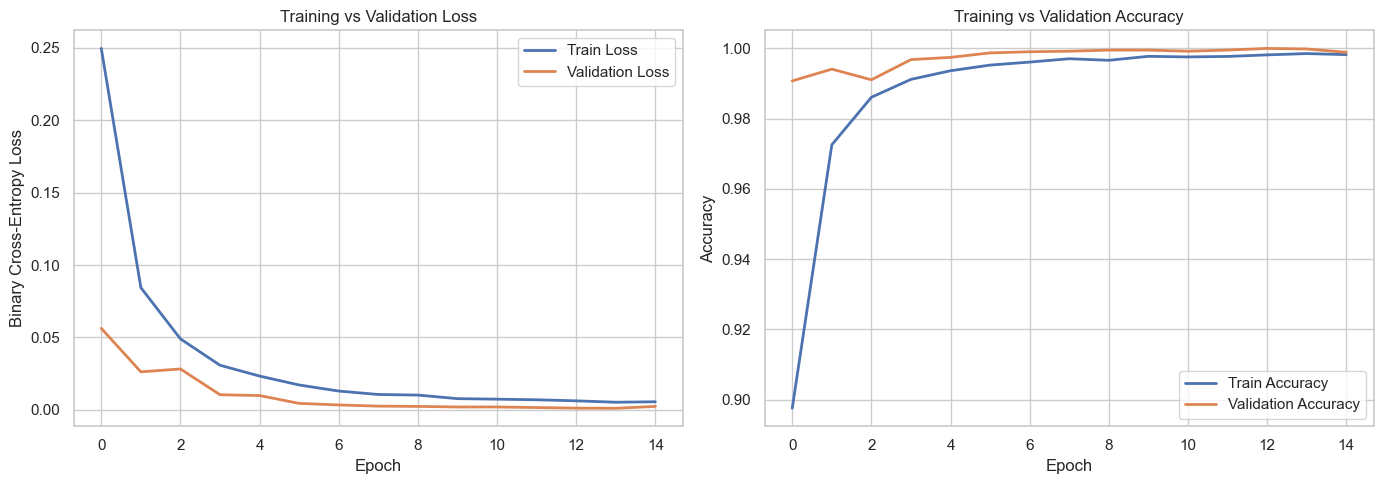

In [10]:
# Plot training curves to visualize optimization progress over time.
# Both accuracy and loss are shown side by side for easier interpretation.
def plot_training_curves(history_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history_df["val_loss"], label="Validation Loss", linewidth=2)
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy Loss")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="Train Accuracy", linewidth=2)
    axes[1].plot(history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print("Plotting training curves...")
plot_training_curves(history_df)


## Step 8: Predict, Smooth, Evaluate, and Export Results

This final stage performs the project deliverables requested in the prompt:
- generate raw test-set probabilities
- convert them to a continuous Drowsiness Index
- smooth the index with a moving average
- compute evaluation metrics
- save the model outputs and report-ready files

### Evaluation Metrics
We report:
- accuracy
- F1-score
- full classification report


784/784 [==============================] - 87s 110ms/step
Test Accuracy: 0.0005
Test F1-Score: 0.0006

Classification Report:

              precision    recall  f1-score   support

  Non Drowsy       0.00      0.00      0.00      2917
      Drowsy       0.00      0.00      0.00      3352

    accuracy                           0.00      6269
   macro avg       0.00      0.00      0.00      6269
weighted avg       0.00      0.00      0.00      6269



,filename,filepath,class_name,label,raw_probability,smoothed_index,predicted_label
0,A0019.png,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,Drowsy,1,0.000007,0.000007,0
1,A0032.png,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,Drowsy,1,0.000003,0.000005,0
2,A0055.png,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,Drowsy,1,0.000018,0.000009,0
3,A0056.png,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,Drowsy,1,0.000006,0.000009,0
4,A0063.png,C:\Users\lenovo\Desktop\Alhnouf CV\Driver Drow...,Drowsy,1,0.000022,0.000011,0


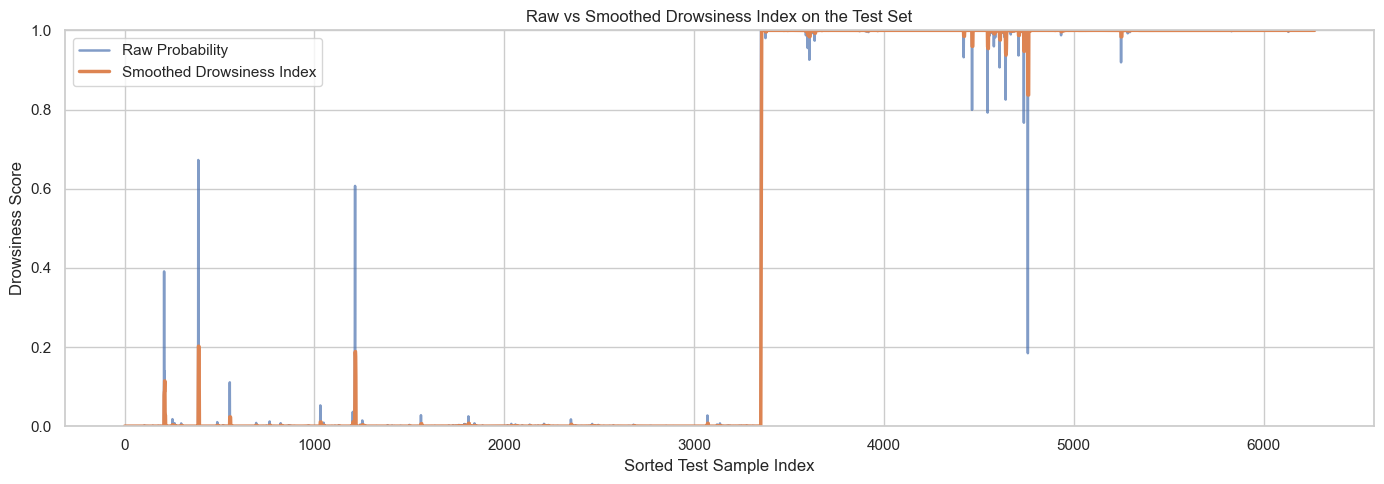

Artifacts saved successfully:
- Best model: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts\best_mobilenetv2_drowsiness.keras
- Drowsiness Index CSV: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts\drowsiness_index.csv
- Detailed predictions: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts\test_predictions_detailed.csv
- Evaluation summary: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts\evaluation_summary.json
- Classification report: C:\Users\lenovo\Desktop\Alhnouf CV\artifacts\classification_report.txt


In [11]:
# Load the best saved checkpoint, run inference on the test set, smooth the Drowsiness Index,
# compute evaluation metrics, and save every important artifact to disk.
def moving_average(values: np.ndarray, window_size: int) -> np.ndarray:
    """Smooth a one-dimensional signal using a trailing moving average."""
    series = pd.Series(values, dtype="float32")
    return series.rolling(window=window_size, min_periods=1).mean().to_numpy()


def predict_with_drowsiness_index(model: keras.Model, split_df: pd.DataFrame, generator) -> pd.DataFrame:
    """Generate raw probabilities and smoothed drowsiness scores for a split."""
    generator.reset()
    raw_probabilities = model.predict(generator, verbose=1).ravel()

    results_df = split_df[["filename", "filepath", "class_name", "label"]].copy().reset_index(drop=True)
    results_df["raw_probability"] = raw_probabilities.astype(float)

    # Sort deterministically before smoothing to emulate a consistent sequence.
    results_df = results_df.sort_values("filename").reset_index(drop=True)
    results_df["smoothed_index"] = moving_average(
        results_df["raw_probability"].to_numpy(),
        window_size=SMOOTHING_WINDOW,
    )
    results_df["predicted_label"] = (results_df["raw_probability"] >= 0.5).astype(int)
    return results_df


def evaluate_predictions(results_df: pd.DataFrame):
    """Compute scalar metrics and classification reports from the prediction table."""
    y_true = results_df["label"].to_numpy()
    y_pred = results_df["predicted_label"].to_numpy()

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=["Non Drowsy", "Drowsy"],
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Non Drowsy", "Drowsy"],
        output_dict=True,
    )
    return accuracy, f1, report_text, report_dict


def plot_drowsiness_index(results_df: pd.DataFrame) -> None:
    """Visualize the raw and smoothed continuous drowsiness signal."""
    plt.figure(figsize=(14, 5))
    plt.plot(results_df["raw_probability"].to_numpy(), label="Raw Probability", alpha=0.70, linewidth=1.8)
    plt.plot(results_df["smoothed_index"].to_numpy(), label="Smoothed Drowsiness Index", linewidth=2.5)
    plt.title("Raw vs Smoothed Drowsiness Index on the Test Set")
    plt.xlabel("Sorted Test Sample Index")
    plt.ylabel("Drowsiness Score")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Reload the best checkpoint saved during training to ensure evaluation uses the strongest model.
best_model = keras.models.load_model(MODEL_PATH)
test_results_df = predict_with_drowsiness_index(best_model, test_df, test_gen)
accuracy, f1, report_text, report_dict = evaluate_predictions(test_results_df)

# Save the exact CSV requested in the project prompt.
test_results_df[["filename", "raw_probability", "smoothed_index"]].to_csv(DI_CSV_PATH, index=False)

# Save a richer prediction table that also includes labels and paths for later analysis.
test_results_df.to_csv(DETAILED_PREDICTIONS_PATH, index=False)

# Save both text and tabular versions of the classification report.
with open(CLASSIFICATION_REPORT_PATH, "w", encoding="utf-8") as file:
    file.write(report_text)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(CLASSIFICATION_REPORT_CSV_PATH, index=True)

# Save a compact JSON summary for easy reuse in the final report or README.
evaluation_summary = {
    "dataset_root": str(dataset_root),
    "num_train": int(len(train_df)),
    "num_validation": int(len(val_df)),
    "num_test": int(len(test_df)),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "smoothing_window": SMOOTHING_WINDOW,
    "accuracy": float(accuracy),
    "f1_score": float(f1),
    "model_path": str(MODEL_PATH),
    "drowsiness_index_csv": str(DI_CSV_PATH),
}

with open(EVALUATION_JSON_PATH, "w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=2)

# Print and display the key outcomes directly in the notebook.
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nClassification Report:\n")
print(report_text)
display(test_results_df.head())
plot_drowsiness_index(test_results_df)

print("Artifacts saved successfully:")
print(f"- Best model: {MODEL_PATH}")
print(f"- Drowsiness Index CSV: {DI_CSV_PATH}")
print(f"- Detailed predictions: {DETAILED_PREDICTIONS_PATH}")
print(f"- Evaluation summary: {EVALUATION_JSON_PATH}")
print(f"- Classification report: {CLASSIFICATION_REPORT_PATH}")
